In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import sklearn.metrics as skm
from tqdm import tqdm
import time
from itertools import combinations
from scipy.stats import t, sem
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from dateutil.relativedelta import relativedelta
import boto3
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr, zscore
import math

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-25 22:43:20.514491


### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [4]:
def custom_mapping_ltv(flt_ltv):
    if flt_ltv <= 1.0:
        return 1.0
    elif flt_ltv <= 1.10:
        return 1.10
    elif flt_ltv <= 1.20:
        return 1.20
    elif flt_ltv <= 1.30:
        return 1.30
    else:
        return 1.50

In [5]:
def fit_linear_model(list_month_number, list_mean):
    # init
    cls_model = LinearRegression()
    X = pd.DataFrame({'month_number': list_month_number})
    y = list_mean
    cls_model.fit(X, y)
    flt_int = cls_model.intercept_
    flt_coef = cls_model.coef_[0]
    return flt_int, flt_coef

In [6]:
def extrapolate(tpl_model, int_target_month):
    flt_int = tpl_model[0]
    flt_coef = tpl_model[1]
    return flt_int + (flt_coef * int_target_month)

In [7]:
def fit_simple_linear_model(df, str_iv):
    # tmp
    df_tmp = df.copy()
    # data split
    df_train = df_tmp[df_tmp['data_set'] == 'train'].copy()
    df_valid = df_tmp[df_tmp['data_set'] == 'valid'].copy()
    df_test = df_tmp[df_tmp['data_set'] == 'test'].copy()
    # list cols in model
    list_cols = [
        str_iv,
    ]
    # init
    cls_model = LinearRegression()
    # fit
    cls_model.fit(
        df_train[list_cols], 
        df_train['target'],
    )
    # predict
    y_hat_train = cls_model.predict(df_train[list_cols])
    y_hat_valid = cls_model.predict(df_valid[list_cols])
    y_hat_test = cls_model.predict(df_test[list_cols])
    # get scores
    flt_score_train = np.sqrt(skm.mean_squared_error(
        y_true=df_train['target'], 
        y_pred=y_hat_train,
    ))
    flt_score_valid = np.sqrt(skm.mean_squared_error(
        y_true=df_valid['target'], 
        y_pred=y_hat_valid,
    ))
    flt_score_test = np.sqrt(skm.mean_squared_error(
        y_true=df_test['target'], 
        y_pred=y_hat_test,
    ))
    print(f'IV: {str_iv}')
    print(f'Train: {flt_score_train:0.4f}')
    print(f'Valid: {flt_score_valid:0.4f}')
    print(f'Test: {flt_score_test:0.4f}')
    flt_int = cls_model.intercept_
    print(f'Intercept: {flt_int:0.4f}')
    flt_coef = cls_model.coef_[0]
    print(f'Coefficient: {flt_coef:0.4f}')
    return flt_score_train, flt_score_valid, flt_score_test

### Constants

In [8]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
str_model = '01_ad'
bool_use_only_loss_accounts = True
int_months_to_mature = 60
str_agg_type = 'mean'

Project: 20231010-gen-xii
Task: ad_hoc


### Output directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [10]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get target pulled from DB

In [11]:
str_filename = 'df_loss_all.gzip'
str_uri = f's3://{str_project}/14_loss_forecasting/03_join_data/{str_filename}'
df = pd.read_parquet(str_uri)
df = df[df['months_on_books'] == 24].copy()
dict_rename = {
    'prop_loss': 'target',
}
df.rename(columns=dict_rename, inplace=True)
df['target'] = df['target'] * 2.36 # 24 - 72 mo loss
df['target'] = df['target'].clip(lower=0)
flt_mean_target = df['target'].mean()
print(f'The mean of the target in all funded loans is {flt_mean_target:0.4f}')
df['loss_or_not'] = df['target'].apply(
    lambda x: 1 if x > 0 else 0,
)
#df = df[df['loss_or_not'] == 1]
df

The mean of the target in all funded loans is 0.1670


,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,months_on_books,fltNetChgOff,target,loss_or_not
11307,3062506,2017-08-01,nan,16286.16,11150.0,1.460642,Franchise,24,0.00,0.000000,0
21571,3136234,2017-10-01,nan,19640.00,13425.0,1.462942,Franchise,24,0.00,0.000000,0
9730,3149560,2017-08-01,13.0,13625.00,10900.0,1.250000,Independent,24,0.00,0.000000,0
17268,3155628,2017-09-01,7.0,12183.00,9275.0,1.313531,Independent,24,0.00,0.000000,0
10285,3158358,2017-08-01,13.0,16409.02,13725.0,1.195557,Franchise,24,0.00,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
196362,5939992,2022-02-01,nan,12969.90,10375.0,1.250111,Independent,24,0.00,0.000000,0
196002,5940339,2022-02-01,nan,23990.99,20537.0,1.168184,Independent,24,0.00,0.000000,0
196003,5940766,2022-02-01,nan,24780.00,18500.0,1.339459,Independent,24,12529.10,1.193248,1
195879,5941420,2022-02-01,nan,12960.12,9126.0,1.420131,Independent,24,11251.67,2.048896,1


### Load in model data to get income

In [12]:
# list_cols = [
#     'uniqueid',
#     'bigaccountid__app',
#     'applicationdate__app',
#     'fltgrossmonthly__income_sum',
#     'bitfunded__app',
# ]
# list_str_df = [
#     'train',
#     'valid',
#     'test',
# ]
# list_df = []
# for str_df in tqdm(list_str_df):
#     str_filename = f'df_{str_df}_raw.gzip'
#     str_uri = f's3://{str_project}/{str_model}/01_data_prep/03_train_valid_test_split/{str_filename}'
#     df = pd.read_parquet(
#         str_uri,
#         columns=list_cols,
#     )
#     df = df[df['bitfunded__app'] == 1].copy()
#     df['data_set'] = str_df
#     list_df.append(df)
# df = pd.concat(list_df)

# df.sort_values(by='uniqueid', ascending=True, inplace=True)
# df.drop_duplicates(subset=['uniqueid'], keep='last', inplace=True)

# # get bigaccountid
# df['bigAccountId'] = df['uniqueid'].apply(
#     lambda x: int(str(x)[:7]),
# )

# # set dtime
# df['applicationdate__app'] = pd.to_datetime(df['applicationdate__app'])

# # show
# df

### Join to target

In [13]:
# df = df[pd.notnull(df['bigaccountid__app'])].copy()
# df['bigaccountid__app'] = df['bigaccountid__app'].astype(int)
# df_target['bigAccountId'] = df_target['bigAccountId'].astype(int)
# df = pd.merge(
#     left=df,
#     right=df_target,
#     on='bigAccountId',
#     how='inner',
# )
# # get loss into proportion of amt financed
# #df['target'] = df['target'] / df['AmtFinanced']
# df

### Remove outliers and clip loss to 0

In [14]:
# AmtFinanced
df['z_tmp'] = zscore(df['AmtFinanced']).abs()
df = df[df['z_tmp'] <= 3].copy()

# BookValue
df['z_tmp'] = zscore(df['BookValue']).abs()
df = df[df['z_tmp'] <= 3].copy()

# # fltgrossmonthly__income_sum
# # flt_mean_tmp = df[df['data_set'] == 'train'].copy()['fltgrossmonthly__income_sum'].mean()
# # df['fltgrossmonthly__income_sum'].fillna(flt_mean_tmp, inplace=True)
# df['fltgrossmonthly__income_sum'].fillna(0, inplace=True)
# df['z_tmp'] = zscore(df['fltgrossmonthly__income_sum']).abs()
# df = df[df['z_tmp'] <= 3].copy()

# target
df['z_tmp'] = zscore(df['target']).abs()
df = df[df['z_tmp'] <= 3].copy()

# clip negatives to 0
df['target'] = df['target'].clip(lower=0)

# show
df

,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,months_on_books,fltNetChgOff,target,loss_or_not,z_tmp
11307,3062506,2017-08-01,nan,16286.16,11150.0,1.460642,Franchise,24,0.0,0.000000,0,0.331612
21571,3136234,2017-10-01,nan,19640.00,13425.0,1.462942,Franchise,24,0.0,0.000000,0,0.331612
9730,3149560,2017-08-01,13.0,13625.00,10900.0,1.250000,Independent,24,0.0,0.000000,0,0.331612
17268,3155628,2017-09-01,7.0,12183.00,9275.0,1.313531,Independent,24,0.0,0.000000,0,0.331612
10285,3158358,2017-08-01,13.0,16409.02,13725.0,1.195557,Franchise,24,0.0,0.000000,0,0.331612
...,...,...,...,...,...,...,...,...,...,...,...,...
195236,5939820,2022-02-01,nan,20448.48,17875.0,1.143971,Independent,24,0.0,0.000000,0,0.331612
196362,5939992,2022-02-01,nan,12969.90,10375.0,1.250111,Independent,24,0.0,0.000000,0,0.331612
196002,5940339,2022-02-01,nan,23990.99,20537.0,1.168184,Independent,24,0.0,0.000000,0,0.331612
196003,5940766,2022-02-01,nan,24780.00,18500.0,1.339459,Independent,24,12529.1,1.193248,1,2.028823


### Get means over time

In [15]:
df.sort_values(by='dtmFunded_first', ascending=True, inplace=True)
df['count'] = 1
df

,bigAccountId,dtmFunded_first,intOpenBKType,AmtFinanced,BookValue,loan_to_value,DealerType,months_on_books,fltNetChgOff,target,loss_or_not,z_tmp,count
11307,3062506,2017-08-01,nan,16286.16,11150.0,1.460642,Franchise,24,0.0,0.0,0,0.331612,1
10098,3279112,2017-08-01,7.0,22472.15,16250.0,1.382902,Independent,24,0.0,0.0,0,0.331612,1
10901,3279110,2017-08-01,nan,24790.00,22575.0,1.098117,Franchise,24,0.0,0.0,0,0.331612,1
10097,3279062,2017-08-01,7.0,18168.35,13238.0,1.372439,Franchise,24,0.0,0.0,0,0.331612,1
10096,3278973,2017-08-01,7.0,19395.00,15725.0,1.233386,Franchise,24,0.0,0.0,0,0.331612,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196114,5911332,2022-02-01,7.0,21850.33,17000.0,1.285314,Franchise,24,0.0,0.0,0,0.331612,1
194969,5911317,2022-02-01,nan,25914.21,22100.0,1.172589,Independent,24,0.0,0.0,0,0.331612,1
196113,5911314,2022-02-01,nan,13028.56,11758.0,1.108059,Independent,24,0.0,0.0,0,0.331612,1
195382,5911457,2022-02-01,nan,18904.00,13150.0,1.437567,Independent,24,0.0,0.0,0,0.331612,1


In [16]:
df_grouped = df.groupby(['dtmFunded_first'], as_index=False).agg({
    'loss_or_not': 'mean',
    'target': lambda x: list(x),
    'count': 'sum',
})
df_grouped['month_number'] = range(1, df_grouped.shape[0]+1)
# logic
df_grouped['mean'] = df_grouped['target'].apply(np.mean)

# show
df_grouped

,dtmFunded_first,loss_or_not,target,count,month_number,mean
0,2017-08-01,0.086275,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.8195540581074954, ...",2040,1,0.071878
1,2017-09-01,0.086538,"[0.0, 0.0, 0.926303290224925, 0.0, 0.0, 0.0, 0...",1664,2,0.074145
2,2017-10-01,0.084736,"[0.0, 0.0, 0.0, 0.0, 1.4964908651359707, 0.0, ...",1664,3,0.080758
3,2017-11-01,0.088512,"[0.8962090023527133, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1593,4,0.079782
4,2017-12-01,0.091485,"[0.0, 0.0, 0.6919213141924498, 0.0, 0.0, 0.619...",1421,5,0.083088
5,2018-01-01,0.097153,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1616,6,0.088809
6,2018-02-01,0.083265,"[0.0, 0.0, 0.0, 0.0, 1.2606939439655171, 1.373...",1225,7,0.068909
7,2018-03-01,0.082556,"[0.0, 0.10192976203611395, 0.0, 0.0, 0.0, 0.0,...",1393,8,0.074442
8,2018-04-01,0.077031,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1428,9,0.069931
9,2018-05-01,0.098706,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2087,10,0.093302


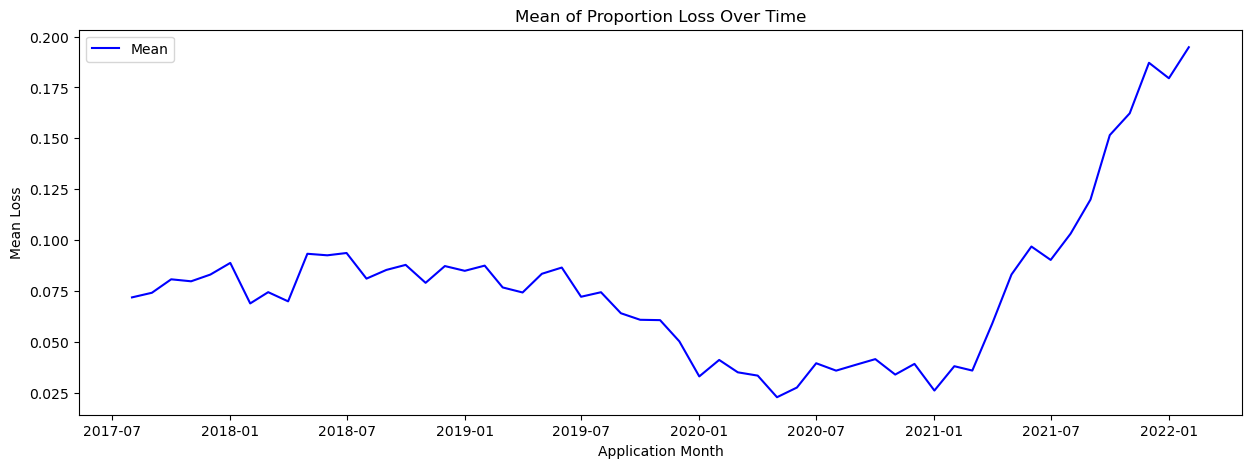

In [17]:
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Mean of Proportion Loss Over Time')
ax.set_ylabel('Mean Loss')
ax.set_xlabel('Application Month')
ax.plot(df_grouped['dtmFunded_first'], df_grouped['mean'], color='blue', label='Mean')
plt.legend()
plt.show()

In [18]:
# get the number of months to extrapolate to
dtm_date_now = dt.datetime.now()
# make 1st of current month 
dtm_date_now = dtm_date_now.replace(day=1)
# set to midnight
dtm_date_now = dtm_date_now.replace(hour=0, minute=0, second=0, microsecond=0)
# get the number of months between the maximum app_month and today
dtm_max = df_grouped['dtmFunded_first'].max()
flt_n_months = (dtm_date_now - dtm_max).days / 30
int_n_months_extrapolate = math.ceil(flt_n_months)
print(f'Projecting {int_n_months_extrapolate} months since the most recent application month')
# get the month number this will be
int_max_months = df_grouped['month_number'].max()
int_target_months = int_max_months + int_n_months_extrapolate
print(f'This means projecting into month {int_target_months} when the maximum was month {int_max_months}')

Projecting 26 months since the most recent application month
This means projecting into month 81 when the maximum was month 55


In [19]:
# get trend of mean
cls_model = LinearRegression()
list_cols = ['month_number']
X = df_grouped[list_cols]
cls_model.fit(X, df_grouped['mean'])
flt_int_mean = cls_model.intercept_
flt_coef_mean = cls_model.coef_[0]

# predict for all months
list_int_months = list(range(1, int_n_months_extrapolate+1))
list_dict_row = []
for int_month in list_int_months:
    dtm_tmp = dtm_max + relativedelta(months=int_month)
    # mean
    flt_mean_loss_yhat = flt_int_mean + (flt_coef_mean * int_month)
    dict_row = {
        'dtmFunded_first': dtm_tmp,
        'month_number': int_month,
        'mean_yhat': flt_mean_loss_yhat,
    }
    list_dict_row.append(dict_row)
df_yhat = pd.DataFrame(list_dict_row)
# concat
df_grouped = pd.concat([df_grouped, df_yhat])
df_grouped

,dtmFunded_first,loss_or_not,target,count,month_number,mean,mean_yhat
0,2017-08-01,0.086275,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.8195540581074954, ...",2040.0,1,0.071878,NaN
1,2017-09-01,0.086538,"[0.0, 0.0, 0.926303290224925, 0.0, 0.0, 0.0, 0...",1664.0,2,0.074145,NaN
2,2017-10-01,0.084736,"[0.0, 0.0, 0.0, 0.0, 1.4964908651359707, 0.0, ...",1664.0,3,0.080758,NaN
3,2017-11-01,0.088512,"[0.8962090023527133, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1593.0,4,0.079782,NaN
4,2017-12-01,0.091485,"[0.0, 0.0, 0.6919213141924498, 0.0, 0.0, 0.619...",1421.0,5,0.083088,NaN
...,...,...,...,...,...,...,...
21,2023-12-01,NaN,NaN,NaN,22,NaN,0.073579
22,2024-01-01,NaN,NaN,NaN,23,NaN,0.074097
23,2024-02-01,NaN,NaN,NaN,24,NaN,0.074615
24,2024-03-01,NaN,NaN,NaN,25,NaN,0.075132


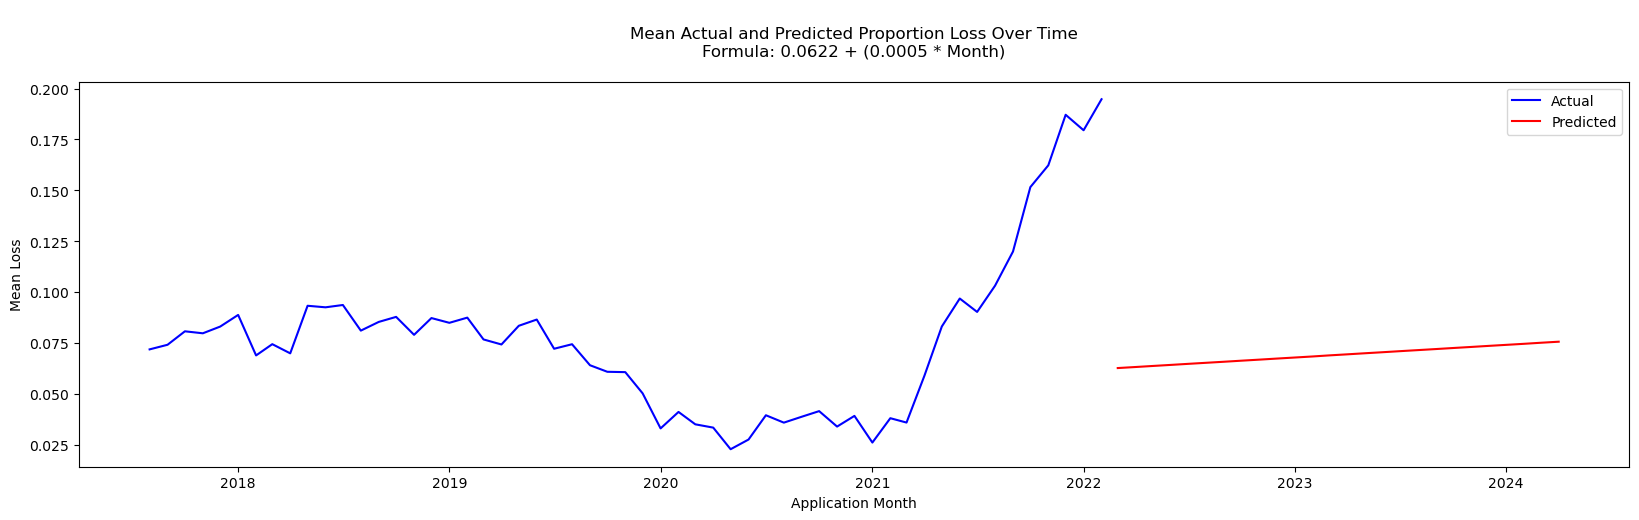

In [20]:
# plot
fig, ax = plt.subplots(figsize=(20,5))
str_title = f"""
Mean Actual and Predicted Proportion Loss Over Time
Formula: {flt_int_mean:0.4f} + ({flt_coef_mean:0.4f} * Month)
"""
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('Mean Loss')
ax.plot(df_grouped['dtmFunded_first'], df_grouped['mean'], color='blue', label='Actual')
ax.plot(df_grouped['dtmFunded_first'], df_grouped['mean_yhat'], color='red', label='Predicted')
plt.legend()
plt.show()

### Project loss by BK Type

In [21]:
%%time

list_app_month = list(df['dtmFunded_first'].unique())
df_tmp = pd.DataFrame({
    'dtmFunded_first': list_app_month,
    'month_number': range(1, len(list_app_month)+1)
})
int_max_month = df_tmp['month_number'].max()
dict_map = dict(zip(df_tmp['dtmFunded_first'], df_tmp['month_number']))

# makke count col
df['count'] = 1

# group
list_cols = [
    'intOpenBKType',
    'dtmFunded_first',
]
df_grouped = df.groupby(list_cols, as_index=False).agg({
    'count': 'sum',
    'target': lambda x: list(x),
})

# get month number and mean
df_grouped['month_number'] = df_grouped['dtmFunded_first'].map(dict_map)

# logic
if str_agg_type == 'mean':
    df_grouped['mean'] = df_grouped['target'].apply(np.mean)
else:
    df_grouped['mean'] = df_grouped['target'].apply(np.median)
df_grouped['count_tmp'] = 1

# group again
list_cols = [
    'intOpenBKType',
]
df_grouped_tmp = df_grouped.groupby(by=list_cols, as_index=False).agg({
    'count_tmp': 'sum',
    'month_number': lambda x: list(x),
    'mean': lambda x: list(x),
})

# fit models
df_grouped_tmp['tpl_model'] = df_grouped_tmp.apply(
    lambda x: fit_linear_model(
        list_month_number=x['month_number'], 
        list_mean=x['mean'],
    ),
    axis=1,
)
df_grouped_tmp['int_target_month'] = int_max_month + int_n_months_extrapolate 

# extrapolate
df_grouped_tmp['predicted_mean'] = df_grouped_tmp.apply(
    lambda x: extrapolate(
        tpl_model=x['tpl_model'], 
        int_target_month=x['int_target_month'],
    ),
    axis=1,
)
# show
df_grouped_tmp

CPU times: user 42.7 ms, sys: 138 µs, total: 42.9 ms
Wall time: 41.7 ms


,intOpenBKType,count_tmp,month_number,mean,tpl_model,int_target_month,predicted_mean
0,13.0,55,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0.04850967442833574, 0.0666153332765598, 0.04...","(0.040489663810649335, -3.794676082383823e-05)",81,0.037416
1,7.0,55,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0.07377460334176714, 0.05764619605024307, 0.0...","(0.045217100823190554, 0.0007333810447659304)",81,0.104621
2,nan,55,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0.07661998474479723, 0.08941801230610408, 0.0...","(0.07515049552631074, 0.00041175547525985196)",81,0.108503


### Trend for LTV and Loss

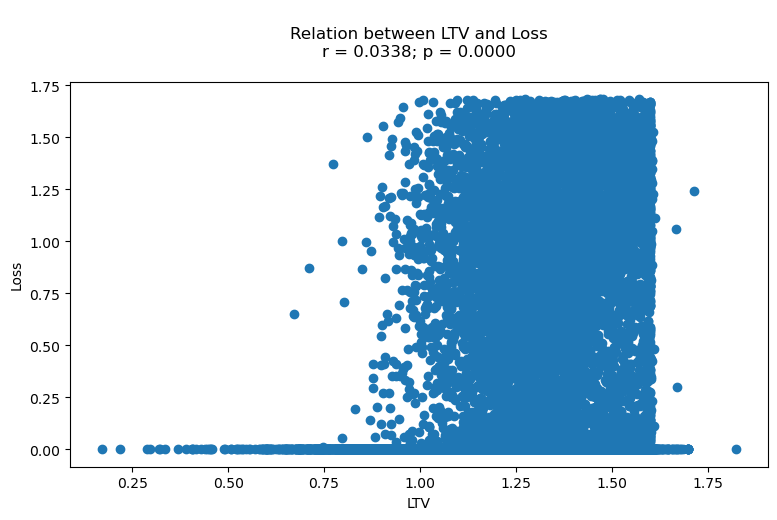

CPU times: user 4.79 s, sys: 139 ms, total: 4.93 s
Wall time: 313 ms


In [22]:
%%time

# get the trend of LTV to loss
flt_coef, flt_p = pearsonr(df['loan_to_value'], df['target'])
str_title = f"""
Relation between LTV and Loss
r = {flt_coef:0.4f}; p = {flt_p:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('LTV')
ax.set_ylabel('Loss')
ax.scatter(df['loan_to_value'], df['target'])
plt.show()

In [23]:
%%time

# fit a simple linear model
list_cols = [
    'loan_to_value',
]
X = df[list_cols]
y = df['target']
cls_model = LinearRegression()
cls_model.fit(X, y)
flt_int_mean = cls_model.intercept_
flt_coef_mean = cls_model.coef_[0]
print(f'Intercept: {flt_int_mean:0.4f}')
print(f'Coefficient: {flt_coef_mean:0.4f}')

Intercept: 0.0031
Coefficient: 0.0584
CPU times: user 24.4 ms, sys: 4.88 ms, total: 29.3 ms
Wall time: 5.55 ms


### Trend for Income and Loss

In [24]:
# %%time

# # get the trend of LTV to loss
# df_tmp = df[df['data_set'] == 'valid'].copy()
# df_tmp['fltgrossmonthly__income_sum'].fillna(0, inplace=True)

# flt_coef, flt_p = pearsonr(df_tmp['fltgrossmonthly__income_sum'], df_tmp['target'])
# str_title = f"""
# Relation between Income and Loss
# r = {flt_coef:0.4f}; p = {flt_p:0.4f}
# """
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title(str_title)
# ax.set_xlabel('Income')
# ax.set_ylabel('Loss')
# ax.scatter(df_tmp['fltgrossmonthly__income_sum'], df_tmp['target'])
# plt.show()

In [25]:
# %%time

# # fit a simple linear model
# list_cols = [
#     'fltgrossmonthly__income_sum',
# ]
# X = df[list_cols]
# y = df['target']
# cls_model = LinearRegression()
# cls_model.fit(X, y)
# flt_int_mean = cls_model.intercept_
# flt_coef_mean = cls_model.coef_[0]
# print(f'Intercept: {flt_int_mean:0.4f}')
# print(f'Coefficient: {flt_coef_mean}')

### Multiple linear model with LTV and Income

In [26]:
# %%time

# # fit a simple linear model
# list_cols = [
#     'ENG-loan_to_value',
#     'fltgrossmonthly__income_sum',
# ]
# X = df[list_cols]
# y = df['target']
# cls_model = LinearRegression()
# cls_model.fit(X, y)
# flt_int_mean = cls_model.intercept_
# list_flt_coef_mean = cls_model.coef_
# dict_coef = dict(zip(list_cols, list_flt_coef_mean))
# print(f'Intercept: {flt_int_mean:0.4f}')
# print(f'Coefficient: {dict_coef}')

### Use the predictions by BK Type and the LTV and Income trend


In [ ]:
dict_bk_type_intercept = dict(zip(df_grouped_tmp['intOpenBKType'], df_grouped_tmp['predicted_mean']))
dict_bk_type_intercept

### Loss by LTV without Income

In [ ]:
flt_coef_ltv = dict_coef['ENG-loan_to_value']
list_flt_ltv = list(np.linspace(0, 1.6, 100))
list_dict_row = []
for flt_ltv in list_flt_ltv:
    # nobk
    flt_loss_nobk = dict_bk_type_intercept['nan'] + (flt_coef_ltv * flt_ltv)
    # bk7
    flt_loss_bk7 = dict_bk_type_intercept['7.0'] + (flt_coef_ltv * flt_ltv)
    # bk13
    flt_loss_bk13 = dict_bk_type_intercept['13.0'] + (flt_coef_ltv * flt_ltv)
    # dict_row
    dict_row = {
        'flt_ltv': flt_ltv,
        'flt_loss_nobk': flt_loss_nobk,
        'flt_loss_bk7': flt_loss_bk7,
        'flt_loss_bk13': flt_loss_bk13,
    }
    list_dict_row.append(dict_row)
df_loss = pd.DataFrame(list_dict_row)

# plot
flt_int_nobk = dict_bk_type_intercept['nan']
flt_int_bk7 = dict_bk_type_intercept['7.0']
flt_int_bk13 = dict_bk_type_intercept['13.0']
# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Predicted Loss by LTV for NoBK, BK7, and BK13
NoBK Loss = {flt_int_nobk:0.4f} + ({flt_coef_ltv:0.4f} * LTV)
BK7 Loss = {flt_int_bk7:0.4f} + ({flt_coef_ltv:0.4f} * LTV)
BK13 Loss = {flt_int_bk13:0.4f} + ({flt_coef_ltv:0.4f} * LTV)
"""
ax.set_title(str_title)
ax.set_xlabel('LTV')
ax.set_ylabel('Predicted Loss')
# nobk
ax.plot(df_loss['flt_ltv'], df_loss['flt_loss_nobk'], label='No BK')
# bk7
ax.plot(df_loss['flt_ltv'], df_loss['flt_loss_bk7'], label='BK 7')
# bk13
ax.plot(df_loss['flt_ltv'], df_loss['flt_loss_bk13'], label='BK 13')
# legend
plt.legend()
# show
plt.show()

### Loss by Income without LTV

In [ ]:
flt_coef_income = dict_coef['fltgrossmonthly__income_sum']
list_flt_income = list(np.linspace(0, 900, 100))
list_dict_row = []
for flt_income in list_flt_income:
    # nobk
    flt_loss_nobk = dict_bk_type_intercept['nan'] + (flt_coef_income * flt_income)
    # bk7
    flt_loss_bk7 = dict_bk_type_intercept['7.0'] + (flt_coef_income * flt_income)
    # bk13
    flt_loss_bk13 = dict_bk_type_intercept['13.0'] + (flt_coef_income * flt_income)
    # dict_row
    dict_row = {
        'flt_income': flt_income,
        'flt_loss_nobk': flt_loss_nobk,
        'flt_loss_bk7': flt_loss_bk7,
        'flt_loss_bk13': flt_loss_bk13,
    }
    list_dict_row.append(dict_row)
df_loss = pd.DataFrame(list_dict_row)

# plot
flt_int_nobk = dict_bk_type_intercept['nan']
flt_int_bk7 = dict_bk_type_intercept['7.0']
flt_int_bk13 = dict_bk_type_intercept['13.0']
# plot
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Predicted Loss by Income for NoBK, BK7, and BK13
NoBK Loss = {flt_int_nobk:0.4f} + ({flt_coef_income} * Income)
BK7 Loss = {flt_int_bk7:0.4f} + ({flt_coef_income} * Income)
BK13 Loss = {flt_int_bk13:0.4f} + ({flt_coef_income} * Income)
"""
ax.set_title(str_title)
ax.set_xlabel('Income')
ax.set_ylabel('Predicted Loss')
# nobk
ax.plot(df_loss['flt_income'], df_loss['flt_loss_nobk'], label='No BK')
# bk7
ax.plot(df_loss['flt_income'], df_loss['flt_loss_bk7'], label='BK 7')
# bk13
ax.plot(df_loss['flt_income'], df_loss['flt_loss_bk13'], label='BK 13')
# legend
plt.legend()
# show
plt.show()